In [1]:
using Pkg
Pkg.activate("../")
using ComponentArrays, Distributions, LinearAlgebra, Plots, StatsBase, ValueFunctionIterations 

  Activating project at `~/github/FisheriesInsuranceModel`


# Bioeconomic model of the demand for production insurance for commercial fisheries

A full description of the model can be found in the manuscript (currently in draft form). This notebook follows the manuscript building out the model piece by piece and then implements a solution usin gthe ValueFunctionIterations.jl library. 

## Annual income from fishing

Income is defined as revenue $\text{price } (P_t) \times \text{catch } (H_t)$ net of variable costs $\text{cost of effort } C_{\text{e},t}^* \times \text{fishing mortaltiy } (f_t)$. See manuscript for a full description of the cost parmaters. 

throughout, including in the code, random variable are write with capital letters and their relized value lower case. 

In [2]:
function income(ht, ft, pt, c_et)
    return pt * ht - c_et * ft 
end 

income (generic function with 1 method)

## Catch and fishing mortaltiy

The level of fishing mortlatiy $f_t$   is set by a harvest control rule that fixes fishing mortality at a constant $f_{\text{target}}$ when the stock is abundant and reduces it when the stock falls below a threshold $b_{\text{target}}$ to zero when the stock falls below a second threshold $$b_{\text{limit}}$. Harvest $H_t$ is determined by the level of fihsing mortaltiy $f_t$ and natrual mortaltiy $M_t$ according to the Baranov catch equation.

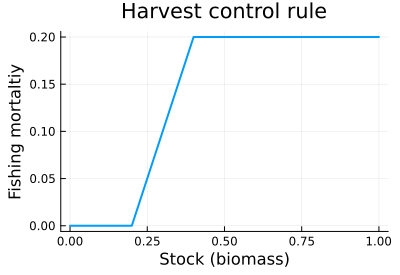

In [3]:

function control_rule(bt,b_target,f_target,b_limit)
    if bt > b_target
        return f_target
    else
        return max(0,f_target*(bt - b_limit) / (b_target - b_limit))
    end
end 


function baranov(bt,mt,ft)
    return ft/(ft+mt)*(1-exp(-mt-ft))*bt
end

x = 0:0.01:1.0
b_target = 0.4; f_target = 0.2; b_limit = 0.2
Plots.plot(x,control_rule.(x,b_target,f_target,b_limit), xlabel = "Stock (biomass)", ylabel = "Fishing mortaltiy", 
            title = "Harvest control rule", linewidth = 2, size = (400,275), label = "")

## Stock dynamics

The stock's dynamics are described by the Deriso-Schnute model with growth rate $g$, mortaltiy $M_t$ and recruitment given by a Beverton-Holt curve $F_R$ with steepness $z$.

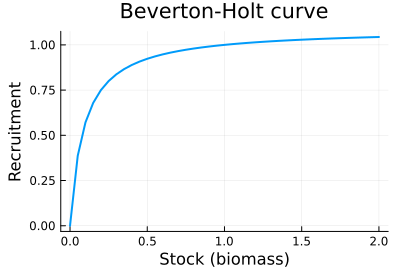

In [4]:
function deriso_schnute(bt,bt_1,mt,mt_1,ft,ft_1,g,FR)
    bt1 = (1+g)*bt*exp(-mt-ft) - g*bt_1*exp(-mt-ft-mt_1-ft_1)+FR
end 

function beverton_holt(bt_τ,b0,r0,z,rt)
    return 4*z*r0*bt_τ*exp(rt)/((1-z)*b0+(5*z-1)*bt_τ)
end 

x = 0:0.05:2.0
b0 = 1.0; r0 = 1.0; z = 0.75; rt = 0
Plots.plot(x,beverton_holt.(x,b0,r0,z,rt), xlabel = "Stock (biomass)", ylabel = "Recruitment", 
            title = "Beverton-Holt curve", linewidth = 2, size = (400,275), label = "")

## Natural mortlatiy 
Mortaltiy rates $M_t$ are driven by an autocorreltated environmetnal variable $X_t$. There is a nonlinear relationship between $X_t$ and mortaltiy $M_t$ with a threshold $x_{\text{threshold}}$ seperating a low and a high mortaltiy regiem with a mortlatiy of $\bar{m}$ in the low mortlatiy regime and increasing mortlatiy in proportion to $x_t$ exceeding the threshold $X$ byt. afactor $m_{\text{slope}}$. 

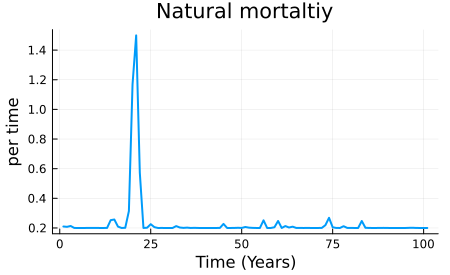

In [5]:
function environment_mortaltiy(xt,m̄,x_threshold,x_sharpness,m_slope)
    m̄ + m_slope/x_sharpness*log(1+exp(x_sharpness*(xt-x_threshold)))
end


function inverse_environment_mortaltiy(mt,m̄,x_threshold,x_sharpness,m_slope)
    log(exp(x_sharpness*(mt-m̄)/m_slope)-1)/x_sharpness+x_threshold
end

# ϵt: random deviation used to update AR 1 process for Xt
function update_mortaltiy(mt,m̄,x_threshold,x_sharpness,m_slope,ρ_X,ϵt)
    xt = inverse_environment_mortaltiy(mt,m̄,x_threshold,x_sharpness,m_slope)
    xt1 = ρ_X*xt + ϵt # σ_X*sqrt(1/(1-ρ_X^2))
    environment_mortaltiy(xt1,m̄,x_threshold,x_sharpness,m_slope)
end 

# simulate mortlatiy for 
T = 100; Mt = zeros(T+1)
x_threshold = 1.75 ;x_sharpness = 4.0 ;m_slope = 1.0; m̄ = 0.2; ρ_X = 0.5; σ_X = 1.0;Mt[1] = m̄+0.01
for t in 1:T
    σ = σ_X/sqrt(1/(1-ρ_X^2))
    ϵt = rand(Distributions.Normal(0,σ))
    Mt[t+1] = update_mortaltiy(Mt[t],m̄,x_threshold,x_sharpness,m_slope,ρ_X,ϵt)
end

Plots.plot(1:(T+1),Mt, xlabel = "Time (Years)", ylabel = "per time", 
            title = "Natural mortaltiy", linewidth = 2, size = (450,275), label = "")


## Insurance contracts

We assume insurnace claims make payments in proportion to how far an index $Z_t$ falls below a threshold value $z_c$. Here, we use the stock's biomass as the index $s_t \equiv b_t$. The claim payments are scaled by the premiums payid $\eta_t$ and the price ofr one unit of exposure demanded by the insurer $\bar{\eta}_t$. 

The price for a unit of premium is determined by the epectedcalims payed by the contract $E[L]$, fixed costs of administering the contract $c_f$ and costs or subsidies $c_v$ that vary with the coverage levels.

Here we calcualte the price assuming we kow the expected losses $E[L]$, but we will have to calcualte these later once we define the probability distributions for all of the random variables in the model.  

In [6]:
function index_insurance(zt,zc,ηt,η̄t)
    ηt/η̄t*max(0,zc-zt)
end 

function price_per_exposure(EL,cf,cv)
    (EL+cf)/(1-cv)
end 

function strike(s,p)
    return 0.5*(p.b_limit+p.b_target)
end 

strike (generic function with 1 method)

## Firm's decision problem and budget constraints

The firm can spend money any savings they have $s_t$ on consumption $\kappa_t$ and insurnace premiums $\eta_t$, plus they can borrow up to a limit $\bar{s}$. This means each period the firm can choose consumption and preimums that satisfy the contraints $\kappa_t >0$, $\eta_t >0$, and $\eta_t + \kappa_t < s_t + \bar{s}$.

Any savings $s_t$ net of consumption and premiums roll over to the next period earning interst $K_t$. Savings can be negative to indicate borrowing.   

The total savings in the following period are equall to the saving that roll over times interest plus fishing income $y_t$ 

if the firms budge constraint falls below zero we assume the firm become bankrupt, which is indicated by the variable $I_{\text{bankrupt}}$, ad all future consumption is equal to a constat $\kappa_{\text{bankrupt}}$.

In [7]:
function budge_constraint(st,s̄)
    return st-s̄
end 

function savings(st,κt, ηt)
    return st - κt - ηt
end 

function update_savings(st,κt, ηt, yt, wt, y0, k)
    s = savings(st,κt, ηt)
    return (1+k)*s + yt + wt + y0
end 

function bankrupt(st,s̄, Ib)
    return (st-s̄  < 0) | (Ib > 1.0)
end 

bankrupt (generic function with 1 method)

## Utility from consumption

We assume the firm gain utility form consumption and seeks to maximize the long run discounted flow of utility form consuming fishing income. If this firm is bakrupt we assume their stream of utility form fishing ends and they revert to a base line utiltiy defined by the consumption level $\kappa_{\text{bankrupt}}$. The firms preferences for consumption are determined by constant relative risk aversion with paramter $\gamma$.

In [8]:
function utility(κt,I_bankrupt,κ_bankrupt,γ)
    if I_bankrupt > 1.0 
        return (κ_bankrupt^(1-γ)-1)/(1-γ)
    end
    return (κt^(1-γ)-1)/(1-γ)
end 

utility (generic function with 1 method)

## Defining random variables for the model

- $P_t$: Prices
- $C_{\text{e},t}^*$: Costs
- $R_t$: Deviations in recruitment function  
- $X_t$: Mortaltiy process
 
### State variables

- $I_{\text{bankrupt}}$: indicator if bankrupt
- $s_t$: Savings
- $b_t$: stock abundnace
- $\Delta b_t$: change in the stock
- $m_{t-1}$: mortaltiy in the last period

In [9]:
function X(s,p)
    Ib,st,bt,Δbt,mt=s
    if Ib >1.0
        return RandomVariable([0.0;;], [1.0])
    end 
    # calcualte mortaltiy process from last period using mortatiy rates
    Xt_1 = inverse_environment_mortaltiy(mt,p.m̄,p.x_threshold,p.x_sharpness,p.m_slope)
    μ_Xt = p.ϕ_X*Xt_1
    σ_Xt = p.σ_X/sqrt(1/(1-p.ϕ_X^2))
    μ_Rt = -1*p.ρ_RX*p.σ_R*Xt_1/p.σ_X
    σ_Rt = (1-p.ρ_RX)*p.σ_R
    μt = [μ_Xt,μ_Rt]
    Σt = [σ_Xt 0; 0 σ_Rt]
    X1 = GaussHermiteRandomVariable(4,μt,Σt)
    X2 = RandomVariable([p.μ_P; p.μ_Ce;;], [1.0,1.0])
    return product(X1,X2)
end 

X_ = ValueFunctionIterations.RandomVariableFunction(X)

ValueFunctionIterations.RandomVariableFunction(X)

## Define action spaces for the dynamic program

In [10]:
κ_grid = 0.0:0.05:1.0
η_grid = 0.0:0.05:0.2
k=0
action_grid = zeros(2,length(κ_grid)*length(η_grid))
for (i,j) in Iterators.product(1:length(κ_grid),1:length(η_grid))
    k +=1
    action_grid[:,k] = vcat(κ_grid[i],η_grid[j]) 
end
action_grid=action_grid[:,reshape(mapslices(sum,action_grid,dims = 1).<=1,length(κ_grid)*length(η_grid))]

function u(s,p)

    Ib,st,bt,Δbt,mt=s
    budget_constraint = st-p.s̄

    if (Ib > 1.0 )| (budget_constraint <= 0.0)
        return [0.0; 0.0;;]
    end

    return budget_constraint .* action_grid
end



u (generic function with 1 method)

## Define paramters for the model

In [116]:

function R0(b0,m̄,g)
    return b0*(1-exp(-m̄,))*(1-g*exp(-m̄))
end 

function f_spr(spr,m̄,g)
    a = spr*g*exp(-2*m̄)
    b = -1*spr*(1+g)*exp(-m̄)
    c = spr - 1 + exp(-m̄) + g*exp(-m̄) - g*exp(-2*m̄)
    -log((-b-sqrt(b^2-4*a*c))/(2*a))
end 

g = exp(-0.2) # somatic growth rate 
m̄ = 0.2 # base line mortality rate  
b0 = 1.0 # biomass without fishing
spr = 0.5 # target spawning potential ratio 

p = ComponentArray(
    (   
        b0 = b0, g = g, m̄ = m̄, # growth paramters 
        r0 = R0(b0,m̄,g), # recruitment without fishing
        z = 0.75, # stock recruitment steepness
        b_target = 0.4, # target reference point 
        b_limit = 0.2, # limit reference point 
        f_target = f_spr(spr,m̄,g), # target fishign mortality rate
        x_threshold = 1.75, # threshold for increasing natrual mortaltiy 
        x_sharpness = 4.0, # steepness of transition from low to high mortlatiy 
        m_slope = 1.5, # effect of environment X on mortlatiy above threshold
        ϕ_X = 0.5, # Autocorrelation of environment X
        σ_X = 1.0, # standard deviation of environment X (stationary dsn)
        ρ_RX = 0.75, # correlation between environemtn Xt and recruitment 
        σ_R = 0.5, # variance of recruitment deviations
        μ_P = 20.0, # mean price for catch 
        μ_Ce = 4.0, # Mean cost of effort 
        s̄ = -2.0, # borrowing budget_constraint
        k = 0.0, # inflation adjusted interest rate
        y0 = -0.4, # fixed cost / alterantive income 
        cf = 0.0, # fixed insuance costs
        cv = 0.0, # variable insurance costs,
        κ_bankrupt = 0.0, # consumption when bankrupt
        γ = 0.0 # Risk aversion 
    )
)

ComponentVector{Float64}(b0 = 1.0, g = 0.8187307530779818, m̄ = 0.2, r0 = 0.0597608369804053, z = 0.75, b_target = 0.4, b_limit = 0.2, f_target = 0.13840170927472387, x_threshold = 1.75, x_sharpness = 4.0, m_slope = 1.5, ϕ_X = 0.5, σ_X = 1.0, ρ_RX = 0.75, σ_R = 0.5, μ_P = 20.0, μ_Ce = 4.0, s̄ = -2.0, k = 0.0, y0 = -0.4, cf = 0.0, cv = 0.0, κ_bankrupt = 0.0, γ = 0.0)

In [117]:
function f_spr(spr,m̄,g)
    a = spr*g*exp(-2*m̄)
    b = -1*spr*(1+g)*exp(-m̄)
    c = spr - 1 + exp(-m̄) + g*exp(-m̄) - g*exp(-2*m̄)
    log((-b-sqrt(b^2-4*a*c))/(2*a))
end 
-f_spr(0.5,m̄,g)

0.13840170927472387

## calcualte expected losses from insurance 

In [123]:
## calculate insurance premiums
using Interpolations

function update_index(s,X,p)
    Ib,st,bt,Δbt,mt_1=s # unpack states
    Xt,rt,pt,c_et = X # unpack random variable
    mt = environment_mortaltiy(Xt,p.m̄,p.x_threshold,p.x_sharpness,p.m_slope)
    bt_1 = bt-Δbt # calcaulte lagged state
    ft = control_rule(bt,p.b_target,p.f_target,p.b_limit) # lagged fishing mortlatiy 
    ft_1 = control_rule(bt_1,p.b_target,p.f_target,p.b_limit) # lagged fishing mortlatiy 
    FR = beverton_holt(bt_1,p.b0,p.r0,p.z,rt) # recruitmemt
    bt1 = deriso_schnute(bt,bt_1,mt,mt_1,ft,ft_1,p.g,FR) # pop model 
    return bt1
end 

function iterpolate_El(bt_grid,Δb_grid,mt_grid,p)
    El = zeros(length(bt_grid),length(Δb_grid),length(mt_grid))
    Nbt = length(bt_grid); NΔb = length(Δb_grid); Nmt = length(mt_grid)
    for (i,j,k) in Iterators.product(1:Nbt,1:NΔb,1:Nmt)
        bt = bt_grid[i]; Δb = Δb_grid[j]; mt = mt_grid[k]
        s = [0.0,0.0,bt,Δb,mt]
        Xt = X(s,p) 
        zt = mapslices(x -> update_index(s,x,p), Xt.nodes, dims = 1) 
        zc = strike(s,p)
        wts = reshape(index_insurance.(zt,zc,1,1),length(Xt.weights))
        Lt = sum(wts.*Xt.weights)
        El[i,j,k] = Lt
    end
    interp=interpolate(El,BSpline(Cubic(Line(OnGrid()))))
    interp=Interpolations.scale(interp,bt_grid,Δb_grid,mt_grid)
    interp= extrapolate(interp, Flat())
    return interp
end 


bt_grid = 0.0:0.05:1.5
Δb_grid = -0.25:0.05:0.5
mt_grid = (p.m̄+0.001):0.05:1.0

El = iterpolate_El(bt_grid,Δb_grid,mt_grid,p)
nothing

## Define state transition functions 

In [124]:
function F(s,u,X,p)

    Ib,st,bt,Δbt,mt_1=s # unpack states

    # if bankrupt stay bankrupt
    if Ib > 1.0
        return [2.0, 0.0, 0.0, 0.0, 0.0]
    end

    κt,ηt=u # unpack actions
    Xt,rt,pt,c_et = X # unpack random variable
    mt = environment_mortaltiy(Xt,p.m̄,p.x_threshold,p.x_sharpness,p.m_slope)

    # calculate fishing mortlatiy rate from harvest cotnrol rule 
    ft = control_rule(bt,p.b_target,p.f_target,p.b_limit)

    # calculate harvest with Baranov equation
    ht = baranov(bt,mt,ft)

    # calculate income from fishing 
    yt = income(ht, ft, pt, c_et)

    # update population
    bt_1 = bt-Δbt # calcaulte lagged state
    ft = control_rule(bt,p.b_target,p.f_target,p.b_limit) # lagged fishing mortlatiy 
    ft_1 = control_rule(bt_1,p.b_target,p.f_target,p.b_limit) # lagged fishing mortlatiy 
    FR = beverton_holt(bt_1,p.b0,p.r0,p.z,rt) # recruitmemt
    bt1 = deriso_schnute(bt,bt_1,mt,mt_1,ft,ft_1,p.g,FR) # pop model

    # calcualte insurance 
    zc = strike(s,p)
    η̄ = price_per_exposure(El(bt,Δbt,mt_1),p.cf,p.cv)
    wt = index_insurance(bt1,zc,ηt,η̄)
    
    # update savings
    st1 = update_savings(st,κt, ηt, yt, wt, p.y0, p.k)

    # if budget constaint is violated go bankrupt 
    if bankrupt(st1,p.s̄,Ib)
        return [2.0,st1,bt1,bt1-bt, mt]
    end 


    return [1.0,st1,bt1,bt1-bt, mt]
end 


function R(s,u,X,p)
    Ib=s[1] # get bankruptcy
    κt=u[1] # get consumption
    utility(κt,Ib,p.κ_bankrupt,p.γ)
end 

R (generic function with 1 method)

## Define value function 

In [125]:
s_grid = -1.99:0.25:2.001
b_grid = 0.0:0.1:1.0
Δb_grid = -0.3:0.1:0.1
mt = (p.m̄+0.001):0.2:1.2

0.201:0.2:1.001

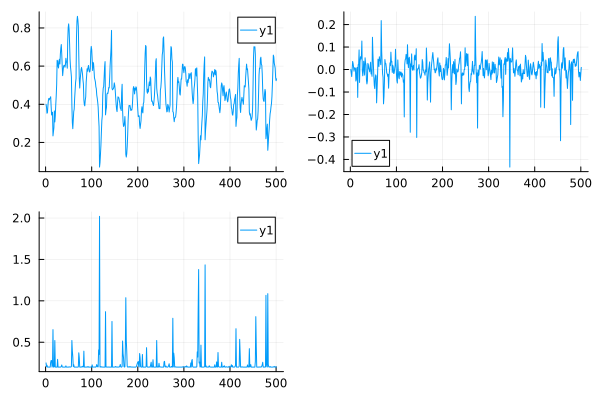

In [126]:
T = 500
svals = zeros(5,T+1)
svals[:,1] = [0.0,1.0,0.4,0.0,0.25]
for t in 1:T
    Xt = X(svals[:,t],p)
    ind = sample(1:length(Xt.weights),Weights(Xt.weights))
    ut = [0.0,0.0]
    svals[:,t+1] = F(svals[:,t],ut,Xt.nodes[:,ind],p)
end 
p1=Plots.plot(svals[3,:])
p2=Plots.plot(svals[4,:])
p3=Plots.plot(svals[5,:])
plot(p1,p2,p3)

## Set up dynamic program 

In [127]:
V = ValueFunction(2,[[s_grid, b_grid, Δb_grid, mt],[0:1,0:1,0:1,0:1]])
δ = 0.95
prob = DynamicProgram(V, R, F, p, u,  X_, δ; solve = false)
estimate_time(prob)

The wieght in the random variable do not add to one, there might be an issue with your integration method.

("Estimate (sec)" => 397.56, "One call" => 9.907007217407226e-6, "Number of computations" => 6688256, "actions" => "varaible", "states" => 4416, "random variable samples" => 16, "Estimated iterations" => 60, "Number of threads" => 10)

In [129]:
solve!(prob)

Progress: 100%|█████████████████████████████████████████| Time: 0:20:30


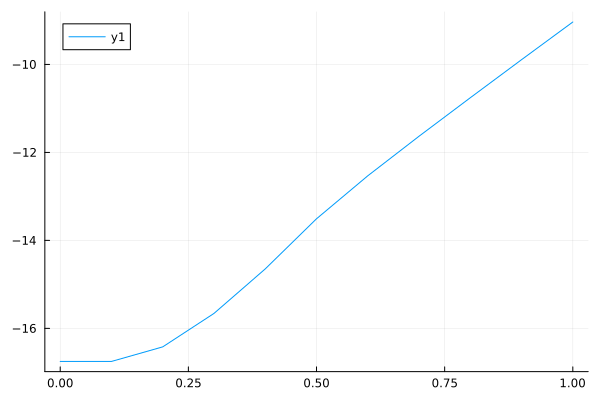

In [131]:
V = broadcast(b -> prob.V([1.0,0.0,b,0.0,0.21]), b_grid)
Plots.plot(b_grid,V)

In [97]:
prob.V.states[:,1]

5-element Vector{Float64}:
  1.0
 -2.0
  0.0
 -0.5
  0.201